Instalasi Library

In [1]:
!pip install networkx matplotlib

Struktur Data Graf Dan Algoritma

In [2]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths (graph, start):
  distances = {node: float('inf') for node in graph}
  distances [start] = 0
  previous = {node: None for node in graph}
  queue = [(0, start)]

  while queue:
    current_distance, current_node = heapq.heappop (queue)

    for neighbor, weight in graph [current_node].items ():
      distance = current_distance + weight
      if distance < distances [neighbor]:
        distances [neighbor] = distance
        previous [neighbor] = current_node
        heapq.heappush (queue, (distance, neighbor))

  return distances, previous

Fungsi Untuk Merekonstruksi Jalur

In [3]:
def get_path (previous, target):
  path = []
  while target is not None:
    path.insert (0, target)
    target = previous [target]
  return path

Visualisasi dengan networkx dan matplotlib

In [4]:
def visualize_graph (graph, path=None):
  G = nx. DiGraph ()

  for node in graph:
      for neighbor, weight in graph [node].items () :
        G.add_edge (node, neighbor, weight=weight)
  pos = nx.spring_layout (G)
  edge_labels = nx.get_edge_attributes (G, 'weight')

  plt.figure (figsize=(8, 6))
  nx.draw (G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold', arrows=True)
  nx.draw_networkx_edge_labels (G, pos, edge_labels=edge_labels)

  # Garis tebal untuk jalur terpendek
  if path and len (path) > 1:
    path_edges = list (zip (path, path[1:]))
    nx.draw_networkx_edges (G, pos, edgelist=path_edges, edge_color='red', width=3)

  plt.title("Visualisasi Graf dan Jalur Terpendek")
  plt.axis ('off')
  plt.show()

Penggunaan Lengkap

Jarak dari A ke Z: 14
Jalur: A → B → D → E → Z


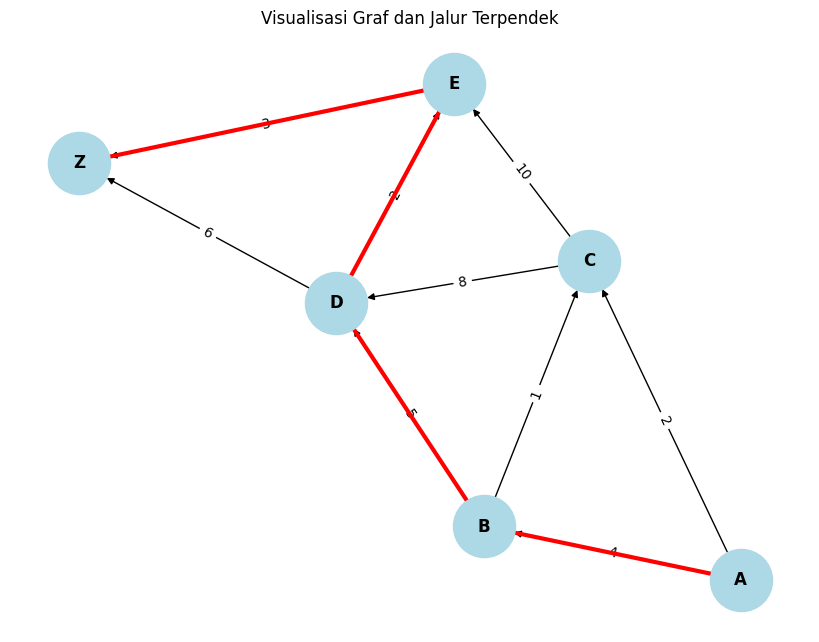

In [5]:
# Definisi graf
graph = {
  'A': {'B': 4, 'C': 2},
  'B': {'C': 1, 'D': 5},
  'C': {'D': 8, 'E':10},
  'D': {'E': 2, 'Z': 6},
  'E': {'Z' : 3},
  'Z': {}
  }

# Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths (graph, start_node)

# Rekonstruksi jalur
shortest_path = get_path (previous, end_node)
print (f"Jarak dari {start_node} ke {end_node}: {distances [end_node]}")
print (f"Jalur: {' → '.join(shortest_path)}")

# Visualisasi
visualize_graph(graph, path=shortest_path)

Modifikasi Graf dengan Siklus

Jarak dari A ke Z: 13
Jalur: A → C → B → D → E → Z


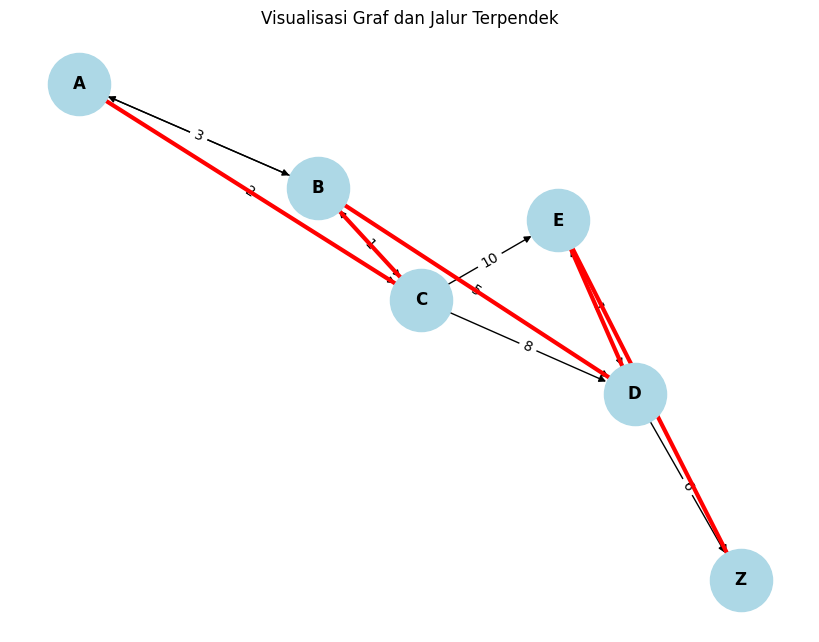

In [7]:
# Graf dengan siklus
graph_siklus = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5, 'A': 3},
    'C': {'D': 8, 'E': 10, 'B': 1},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3, 'D': 1},
    'Z': {}
}

start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths(graph_siklus, start_node)
shortest_path = get_path(previous, end_node)

print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {' → '.join(shortest_path)}")

visualize_graph(graph_siklus, path=shortest_path)

Menambahkan Simpul Baru

Jarak dari A ke Z: 5
Jalur: A → C → F → Z


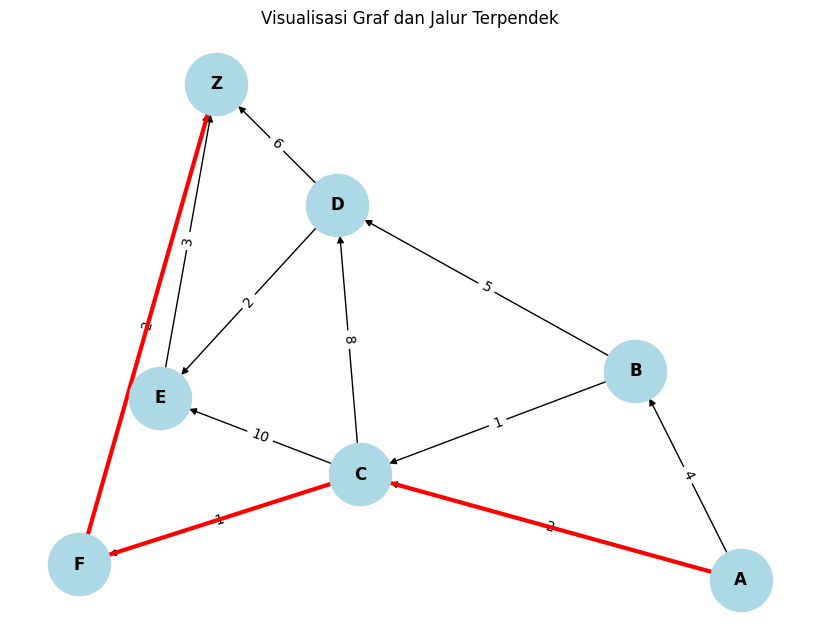

In [8]:
# Graf dengan simpul baru 'F'
graph_baru = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10, 'F': 1},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'F': {'Z': 2},
    'Z': {}
}

start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths(graph_baru, start_node)
shortest_path = get_path(previous, end_node)

print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {' → '.join(shortest_path)}")

visualize_graph(graph_baru, path=shortest_path)

Mengganti Tata Letak Graf

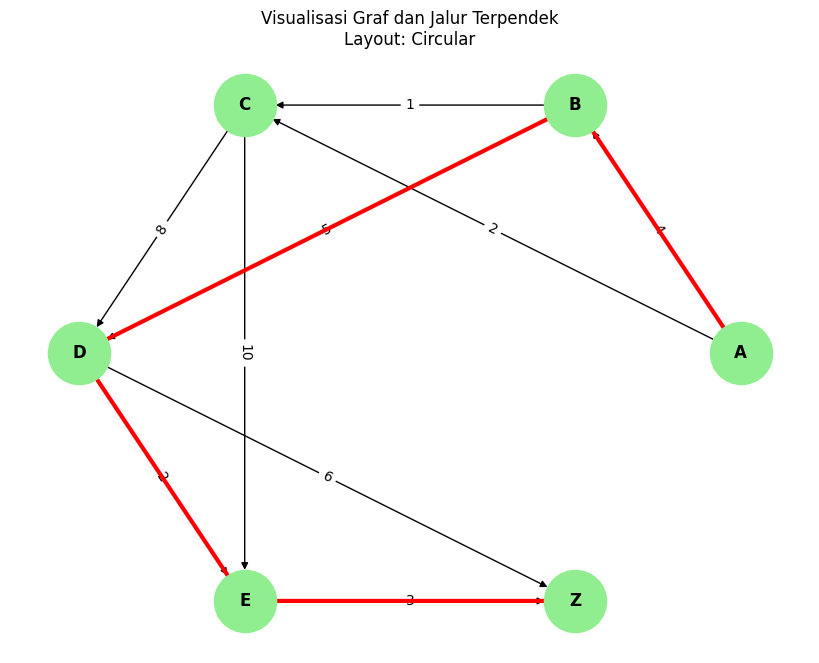

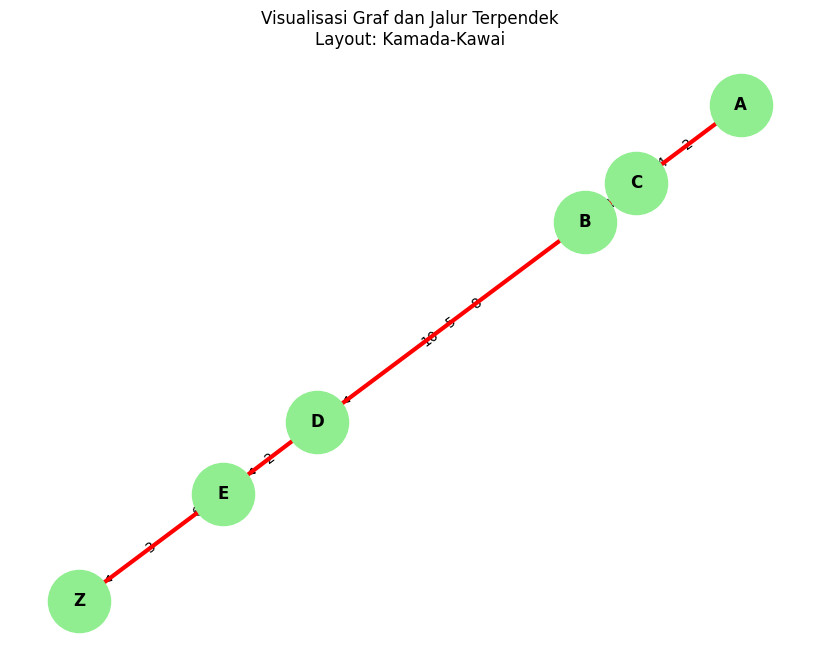

In [9]:
def visualize_graph_layout(graph, path=None, layout='spring'):
    G = nx.DiGraph()
    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    # Pilih layout
    if layout == 'circular':
        pos = nx.circular_layout(G)
        judul = "Layout: Circular"
    elif layout == 'kamada_kawai':
        pos = nx.kamada_kawai_layout(G)
        judul = "Layout: Kamada-Kawai"
    else:
        pos = nx.spring_layout(G)
        judul = "Layout: Spring"

    edge_labels = nx.get_edge_attributes(G, 'weight')
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightgreen',
            node_size=2000, font_weight='bold', arrows=True)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges,
                               edge_color='red', width=3)

    plt.title(f"Visualisasi Graf dan Jalur Terpendek\n{judul}")
    plt.axis('off')
    plt.show()

# Jalankan dengan berbagai layout
distances, previous = dijkstra_with_paths(graph, 'A')
shortest_path = get_path(previous, 'Z')

visualize_graph_layout(graph, path=shortest_path, layout='circular')
visualize_graph_layout(graph, path=shortest_path, layout='kamada_kawai')